###### FaceNet - Identification on LFW
### IMT Nord Europe - Biometrics Project
---

In [1]:
# -- Cell 1: Installation ---------------------------------------------
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "uninstall", "facenet-pytorch", "-y", "-q"])
subprocess.run([sys.executable, "-m", "pip", "install", "facenet-pytorch", "--no-deps", "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "requests", "Pillow", "-q"], check=True)
print(" Installation OK -> run Restart & Run All")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.1 MB/s eta 0:00:00
 Installation OK -> run Restart & Run All


In [2]:
# -- Cell 2: Imports & configuration ----------------------------------
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
from PIL import Image

from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device  : {DEVICE}")
print(f"   NumPy   : {np.__version__}")
print(f"   PyTorch : {torch.__version__}")

 Device  : cuda
   NumPy   : 2.0.2
   PyTorch : 2.10.0+cu128


In [3]:
# -- Cell 3: Automatic detection of the LFW path ----------------------
MIN_IMAGES = 10

def find_lfw_root(base="/kaggle/input"):
    base = Path(base)
    if not base.exists():
        return None
    for path in sorted(base.rglob("*")):
        if path.is_dir():
            subdirs = [x for x in path.iterdir() if x.is_dir()]
            if len(subdirs) > 100:
                sample = subdirs[0]
                if list(sample.glob("*.jpg")):
                    return path
    return None

print(" Contents of /kaggle/input :")
for p in sorted(Path("/kaggle/input").rglob("*")):
    depth = len(p.relative_to("/kaggle/input").parts)
    if depth <= 4:
        print("  " * depth + p.name + ("/" if p.is_dir() else ""))

RAW_DATA_DIR = find_lfw_root("/kaggle/input")
if RAW_DATA_DIR is None:
    raise FileNotFoundError("LFW dataset not found in /kaggle/input.")
print(f"\n LFW root detected : {RAW_DATA_DIR}")

 Contents of /kaggle/input :
  datasets/
    jessicali9530/
      lfw-dataset/
        lfw-deepfunneled/
        lfw_allnames.csv
        lfw_readme.csv
        matchpairsDevTest.csv
        matchpairsDevTrain.csv
        mismatchpairsDevTest.csv
        mismatchpairsDevTrain.csv
        pairs.csv
        people.csv
        peopleDevTest.csv
        peopleDevTrain.csv

 LFW root detected : /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled


 158 people | 4324 images
   Min images / person   : 10
   most images : George_W_Bush (530 imgs)
   fewest images : Bill_McBride (10 imgs)


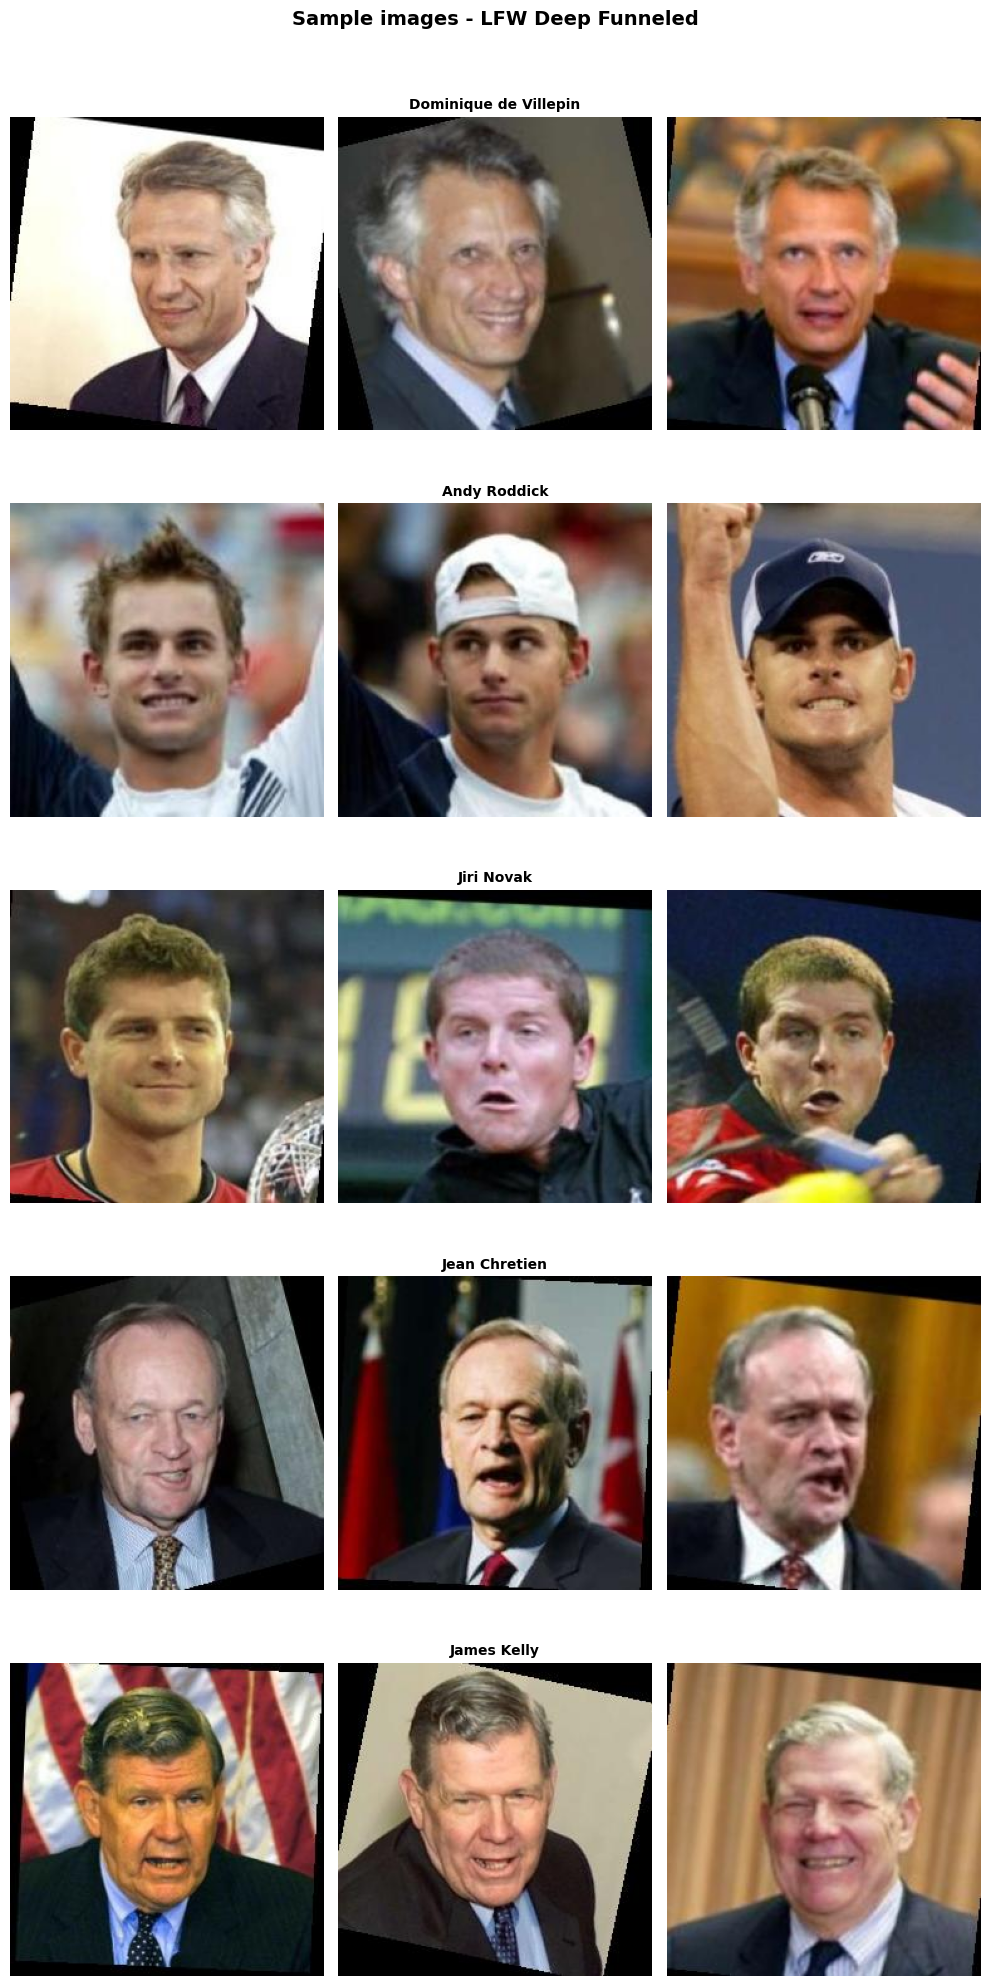

In [4]:
# -- Cell 4: Loading + sample visualisation ---------------------------
def load_lfw_paths(root: Path, min_images: int):
    paths, labels = [], []
    for person_dir in sorted(root.iterdir()):
        if not person_dir.is_dir():
            continue
        imgs = sorted(person_dir.glob("*.jpg"))
        if len(imgs) >= min_images:
            for img in imgs:
                paths.append(img)
                labels.append(person_dir.name)
    return paths, labels

paths, labels = load_lfw_paths(RAW_DATA_DIR, MIN_IMAGES)
unique_labels = sorted(set(labels))
counts = Counter(labels)

print(f" {len(unique_labels)} people | {len(paths)} images")
print(f"   Min images / person   : {MIN_IMAGES}")
print(f"   most images : {max(counts, key=counts.get)} ({max(counts.values())} imgs)")
print(f"   fewest images : {min(counts, key=counts.get)} ({min(counts.values())} imgs)")

# -- Visualisation ----------------------------------------------------
random.seed(42)
sample_persons = random.sample(unique_labels, min(5, len(unique_labels)))

fig, axes = plt.subplots(len(sample_persons), 3, figsize=(10, 4 * len(sample_persons)))
for row, person in enumerate(sample_persons):
    person_imgs = [p for p, l in zip(paths, labels) if l == person]
    chosen = random.sample(person_imgs, min(3, len(person_imgs)))
    for col in range(3):
        ax = axes[row, col]
        if col < len(chosen):
            ax.imshow(Image.open(chosen[col]))
            ax.set_title(person.replace('_', ' ') if col == 1 else "", fontsize=10, fontweight='bold')
        ax.axis('off')
plt.suptitle("Sample images - LFW Deep Funneled", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# -- Cell 5: MTCNN + FaceNet initialisation ---------------------------
mtcnn = MTCNN(image_size=160, margin=20, keep_all=False, device=DEVICE)
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
print(" MTCNN and FaceNet loaded - 512-dimensional embeddings")

  0%|          | 0.00/107M [00:00<?, ?B/s]

 MTCNN and FaceNet loaded - 512-dimensional embeddings


In [6]:
# -- Cell 6: Embedding extraction -------------------------------------
def extract_embeddings(paths, labels, batch_size=64):
    embeddings, valid_labels, valid_paths = [], [], []
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting embeddings"):
        batch_paths  = paths[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        imgs  = [Image.open(p).convert("RGB") for p in batch_paths]
        faces = mtcnn(imgs)
        valid_imgs, valid_labs, valid_ps = [], [], []
        for face, label, p in zip(faces, batch_labels, batch_paths):
            if face is not None:
                valid_imgs.append(face)
                valid_labs.append(label)
                valid_ps.append(p)
        if not valid_imgs:
            continue
        batch_tensor = torch.stack(valid_imgs).to(DEVICE)
        with torch.no_grad():
            emb = facenet(batch_tensor).cpu().numpy()
        embeddings.append(emb)
        valid_labels.extend(valid_labs)
        valid_paths.extend(valid_ps)
    return np.vstack(embeddings), np.array(valid_labels), valid_paths

X, y, valid_paths = extract_embeddings(paths, labels)
X = normalize(X)
print(f"\n Embeddings : {X.shape}")
print(f"   Faces not detected by MTCNN : {len(paths) - len(valid_paths)}")

Extracting embeddings: 100%|██████████| 68/68 [01:04<00:00,  1.05it/s]


 Embeddings : (4324, 512)
   Faces not detected by MTCNN : 0


In [7]:
# -- Cell 7: Encoding & train/test split ------------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y_enc, valid_paths, test_size=0.2, stratify=y_enc, random_state=42
)
print(f" Train : {X_train.shape[0]} | Test : {X_test.shape[0]} | Classes : {len(le.classes_)}")

 Train : 3459 | Test : 865 | Classes : 158


In [8]:
# -- Cell 8: SVM classifier -------------------------------------------
print("Training SVM (kernel=linear)...")
clf = SVC(kernel='linear', probability=True, C=1.0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\n SVM accuracy : {acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Training SVM (kernel=linear)...

 SVM accuracy : 98.61%
                           precision    recall  f1-score   support

             Abdullah_Gul       0.80      1.00      0.89         4
             Adrien_Brody       1.00      1.00      1.00         2
         Alejandro_Toledo       1.00      1.00      1.00         8
             Alvaro_Uribe       1.00      1.00      1.00         7
          Amelie_Mauresmo       1.00      1.00      1.00         4
             Andre_Agassi       1.00      1.00      1.00         7
             Andy_Roddick       1.00      1.00      1.00         3
           Angelina_Jolie       1.00      1.00      1.00         4
              Ann_Veneman       1.00      1.00      1.00         2
          Anna_Kournikova       1.00      1.00      1.00         2
            Ari_Fleischer       1.00      1.00      1.00         3
             Ariel_Sharon       1.00      1.00      1.00        16
    Arnold_Schwarzenegger       1.00      1.00      1.00         8
     

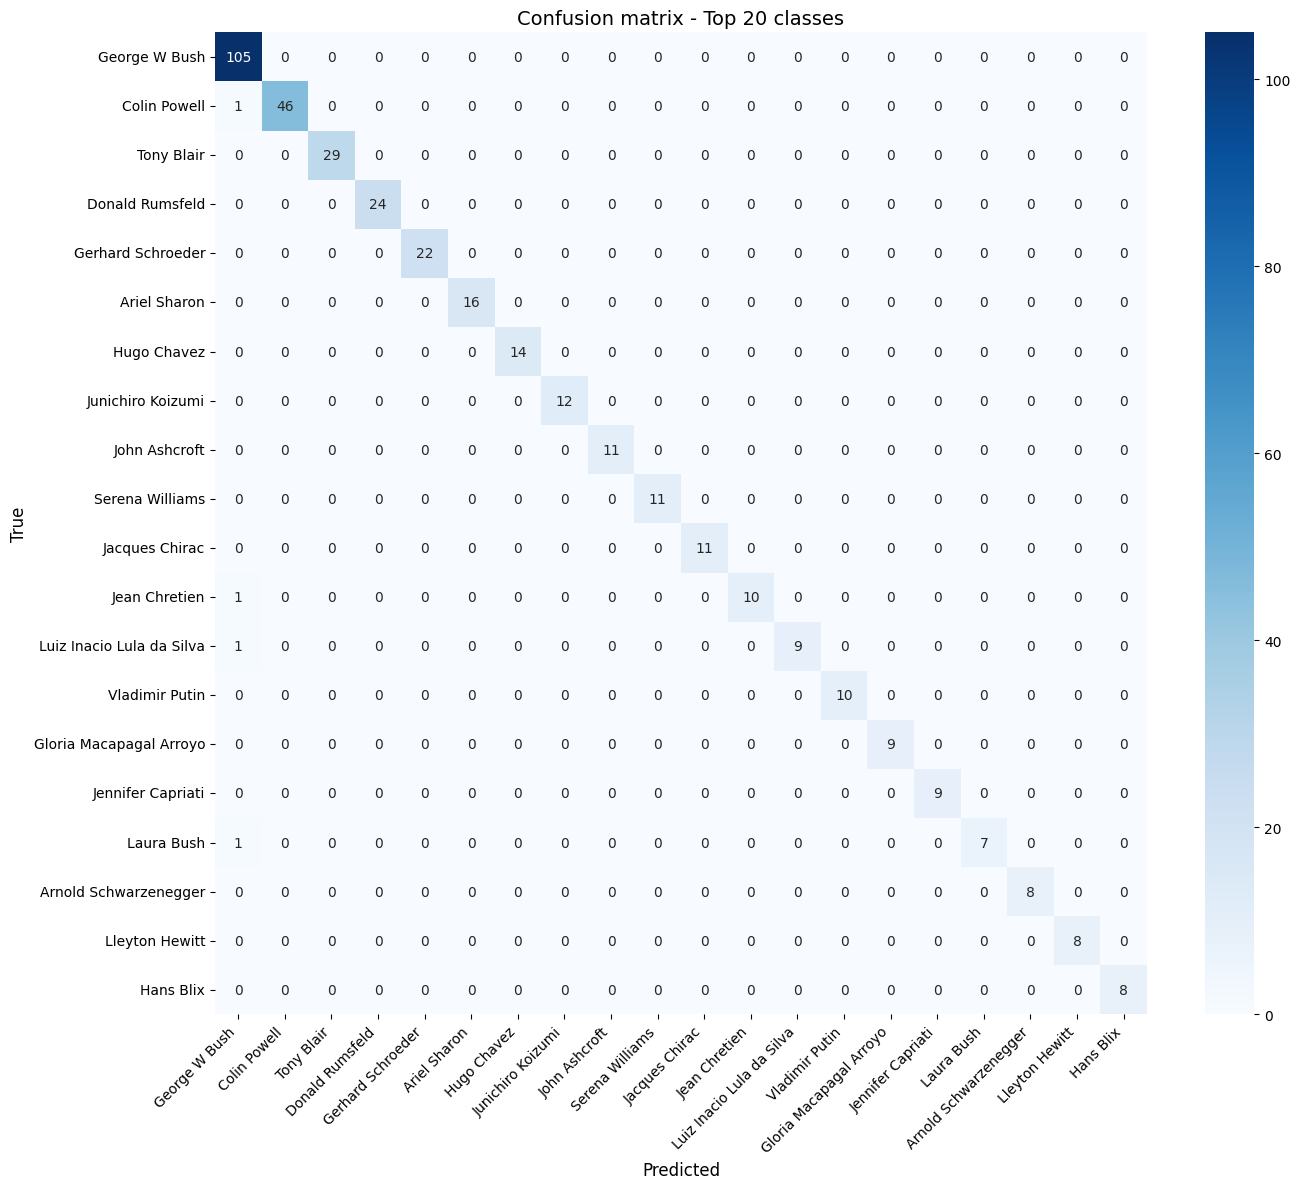


 Rows kept (both labels in top-20) : 383 / 865


In [9]:
# -- Cell 9: Confusion matrix (top-20 classes) ------------------------
# The remap must also cover predictions outside the top-20,
# so mask filters on both y_test AND y_pred being in the top-20

top20_enc   = [enc for enc, _ in Counter(y_test).most_common(20)]
top20_set   = set(top20_enc)
top20_names = le.classes_[top20_enc]

# Keep only rows where both true and predicted labels are in the top-20
mask  = np.array([
    yt in top20_set and yp in top20_set
    for yt, yp in zip(y_test, y_pred)
])
y_t20 = y_test[mask]
y_p20 = y_pred[mask]

remap  = {old: new for new, old in enumerate(top20_enc)}
y_t20r = np.array([remap[v] for v in y_t20])
y_p20r = np.array([remap[v] for v in y_p20])

cm = confusion_matrix(y_t20r, y_p20r, labels=list(range(len(top20_enc))))

# Short names for readability
short_names = [n.replace('_', ' ') for n in top20_names]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=short_names, yticklabels=short_names, cmap='Blues')
plt.title("Confusion matrix - Top 20 classes", fontsize=14)
plt.xlabel("Predicted", fontsize=12); plt.ylabel("True", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n Rows kept (both labels in top-20) : {mask.sum()} / {len(y_test)}")

 12 errors out of 865 (1.4%)


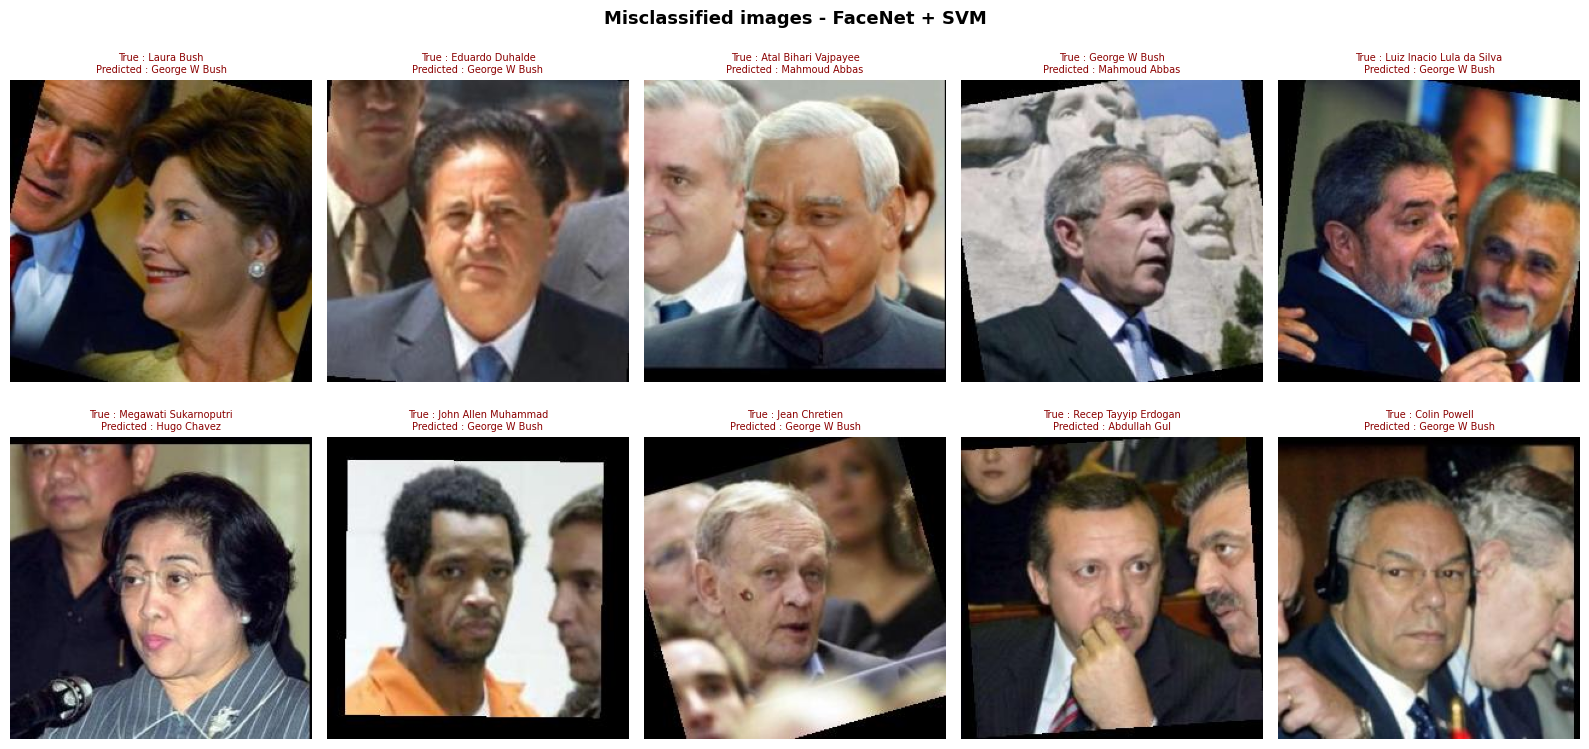

In [10]:
# -- Cell 10: Error analysis ------------------------------------------
errors = np.where(y_test != y_pred)[0]
print(f" {len(errors)} errors out of {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")

if len(errors) == 0:
    print("No errors!")
else:
    n_show = min(10, len(errors))
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if rows > 1 else axes
    for i, err_idx in enumerate(errors[:n_show]):
        true_name = le.classes_[y_test[err_idx]]
        pred_name = le.classes_[y_pred[err_idx]]
        img = Image.open(paths_test[err_idx])
        axes[i].imshow(img)
        axes[i].set_title(
            f"True : {true_name.replace('_',' ')}\nPredicted : {pred_name.replace('_',' ')}",
            fontsize=7, color='darkred'
        )
        axes[i].axis('off')
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    plt.suptitle("Misclassified images - FaceNet + SVM", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Computing t-SNE on 343 points (may take ~1 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


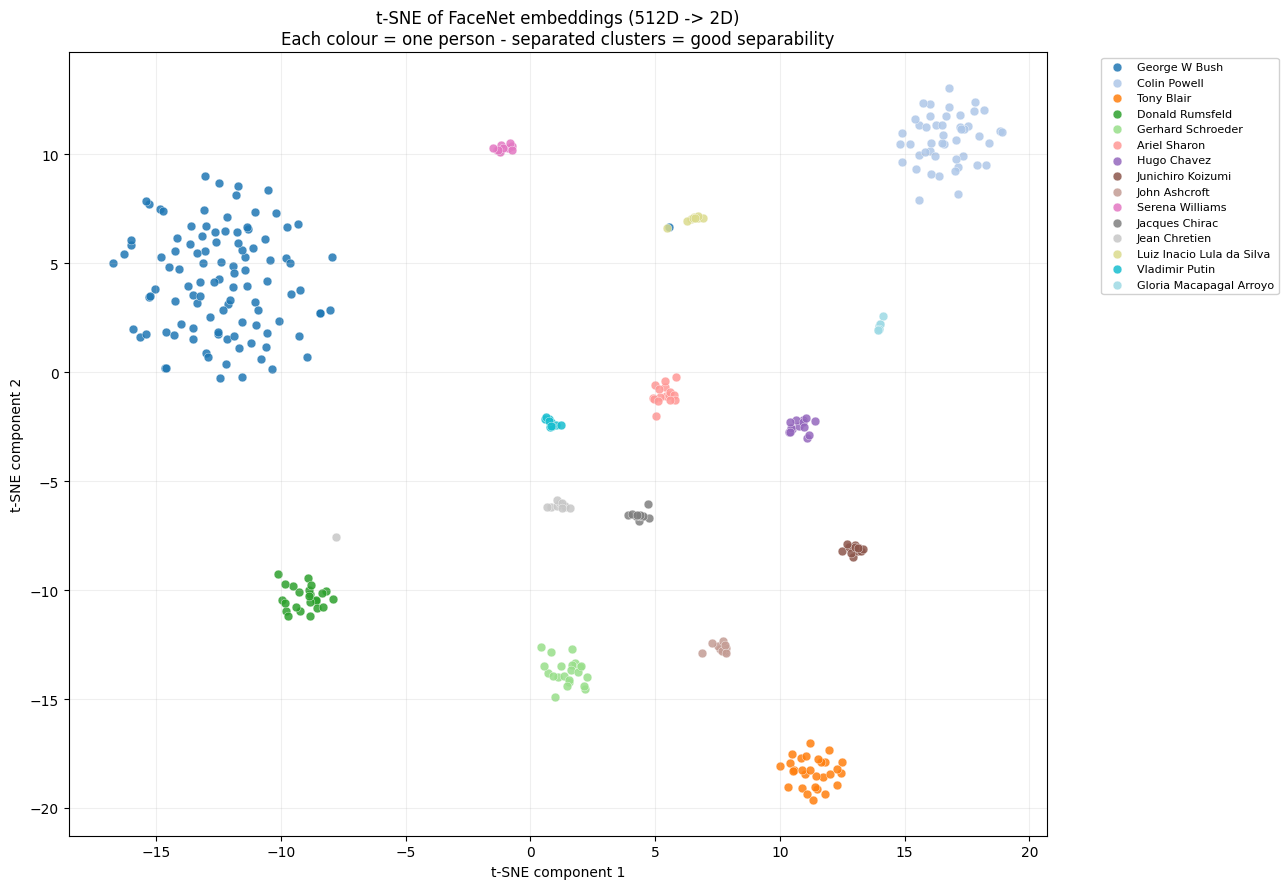


 Interpretation :
   - Well-separated clusters -> FaceNet produces discriminative embeddings
   - Points of the same colour grouped -> good intra-class consistency
   - Overlapping clusters -> visually similar people


In [11]:
# -- Cell 11: t-SNE visualisation of the embeddings -------------------
# t-SNE reduces 512 dimensions -> 2 dimensions for visualisation
# Nearby points = similar embeddings = same person (ideally)
from sklearn.manifold import TSNE

top15_enc   = [enc for enc, _ in Counter(y_test).most_common(15)]
top15_names = le.classes_[top15_enc]

mask15 = np.isin(y_test, top15_enc)
X_vis  = X_test[mask15]
y_vis  = y_test[mask15]

print(f"Computing t-SNE on {X_vis.shape[0]} points (may take ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_vis)

colors = plt.cm.tab20(np.linspace(0, 1, len(top15_enc)))
fig, ax = plt.subplots(figsize=(13, 9))
for i, (enc, name) in enumerate(zip(top15_enc, top15_names)):
    mask_i = y_vis == enc
    ax.scatter(X_2d[mask_i, 0], X_2d[mask_i, 1],
               label=name.replace('_', ' '), s=40, alpha=0.85, color=colors[i], edgecolors='white', linewidths=0.3)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.9)
ax.set_title(
    "t-SNE of FaceNet embeddings (512D -> 2D)\n"
    "Each colour = one person - separated clusters = good separability",
    fontsize=12
)
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n Interpretation :")
print("   - Well-separated clusters -> FaceNet produces discriminative embeddings")
print("   - Points of the same colour grouped -> good intra-class consistency")
print("   - Overlapping clusters -> visually similar people")

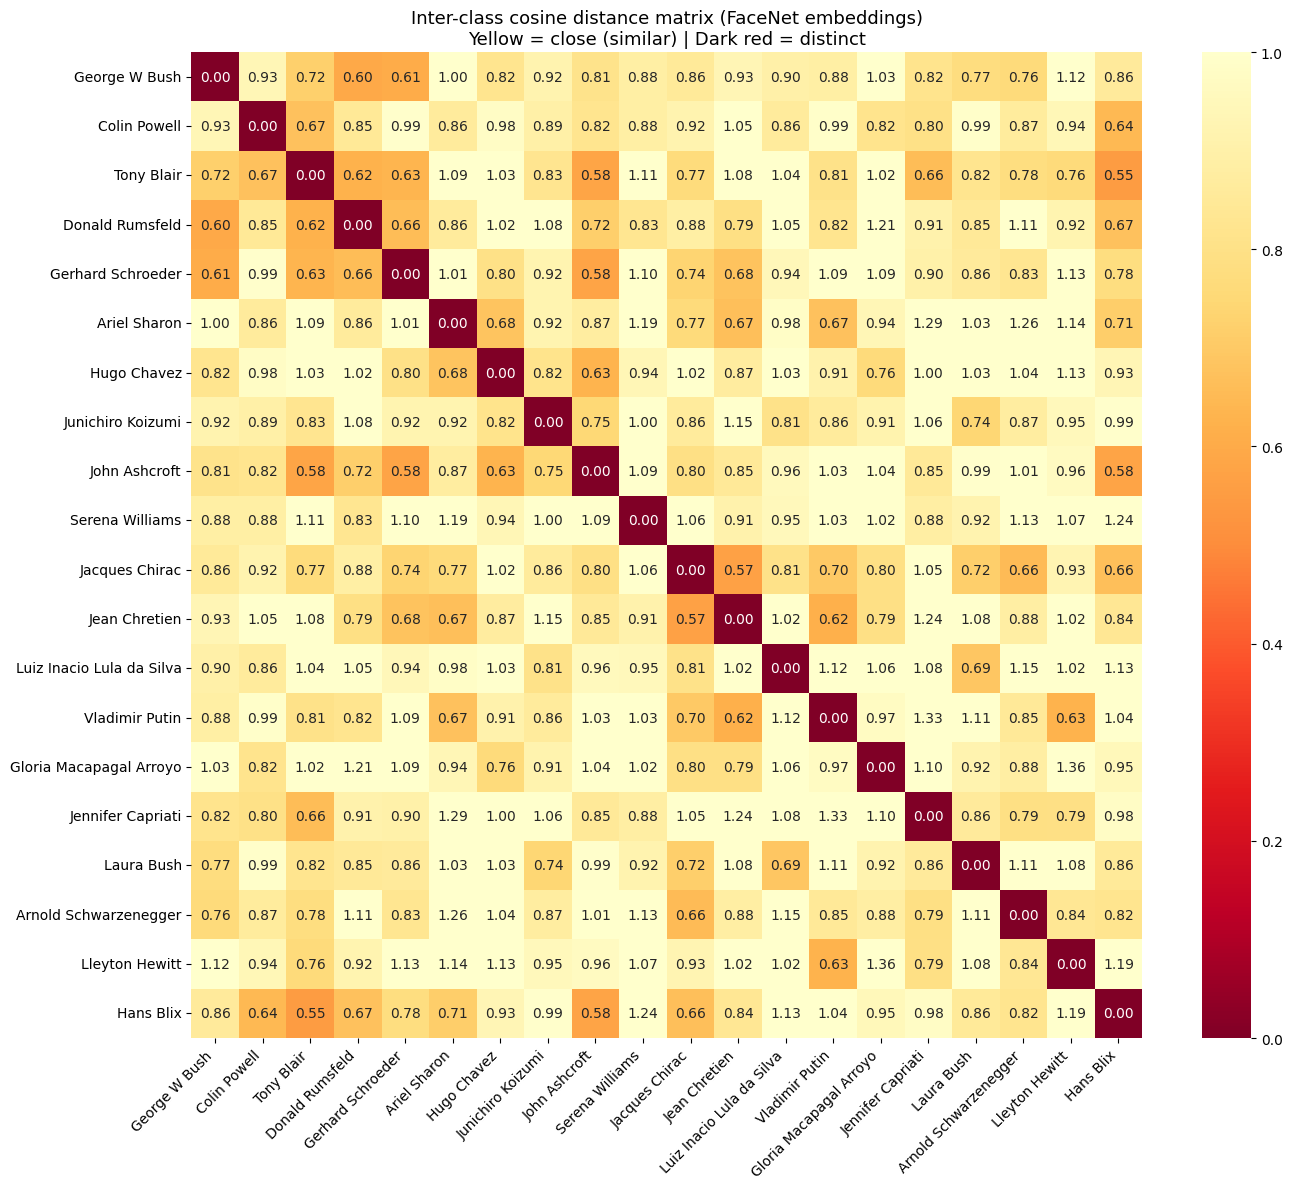


 Top-5 closest pairs (confusion risk) :
   Tony Blair <-> Hans Blix : distance = 0.550
   Jacques Chirac <-> Jean Chretien : distance = 0.567
   Gerhard Schroeder <-> John Ashcroft : distance = 0.577
   John Ashcroft <-> Hans Blix : distance = 0.578
   Tony Blair <-> John Ashcroft : distance = 0.582


In [12]:
# -- Cell 12: Inter-class cosine distance matrix ----------------------
# For each pair of people (top-20):
#   Distance ~ 0 (yellow) -> close embeddings -> similar people -> confusion risk
#   Distance ~ 1 (red)    -> distant embeddings -> clearly distinct people

from sklearn.preprocessing import normalize as sk_normalize

top20_enc   = [enc for enc, _ in Counter(y_test).most_common(20)]
top20_names = [le.classes_[e].replace('_',' ') for e in top20_enc]

# L2-normalised centroid of each class in the test set
centroids = np.array([
    X_test[y_test == enc].mean(axis=0)
    for enc in top20_enc
])
centroids = sk_normalize(centroids)

# Cosine distance = 1 - dot product (vectors already normalised)
dist_matrix = 1 - centroids @ centroids.T
np.fill_diagonal(dist_matrix, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(dist_matrix, annot=True, fmt='.2f',
            xticklabels=top20_names, yticklabels=top20_names,
            cmap='YlOrRd_r', vmin=0, vmax=1)
plt.title(
    "Inter-class cosine distance matrix (FaceNet embeddings)\n"
    "Yellow = close (similar) | Dark red = distinct",
    fontsize=13
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top-5 closest pairs = potential confusions
pairs = []
for i in range(len(top20_enc)):
    for j in range(i+1, len(top20_enc)):
        pairs.append((dist_matrix[i,j], top20_names[i], top20_names[j]))
pairs.sort()
print("\n Top-5 closest pairs (confusion risk) :")
for dist, n1, n2 in pairs[:5]:
    print(f"   {n1} <-> {n2} : distance = {dist:.3f}")

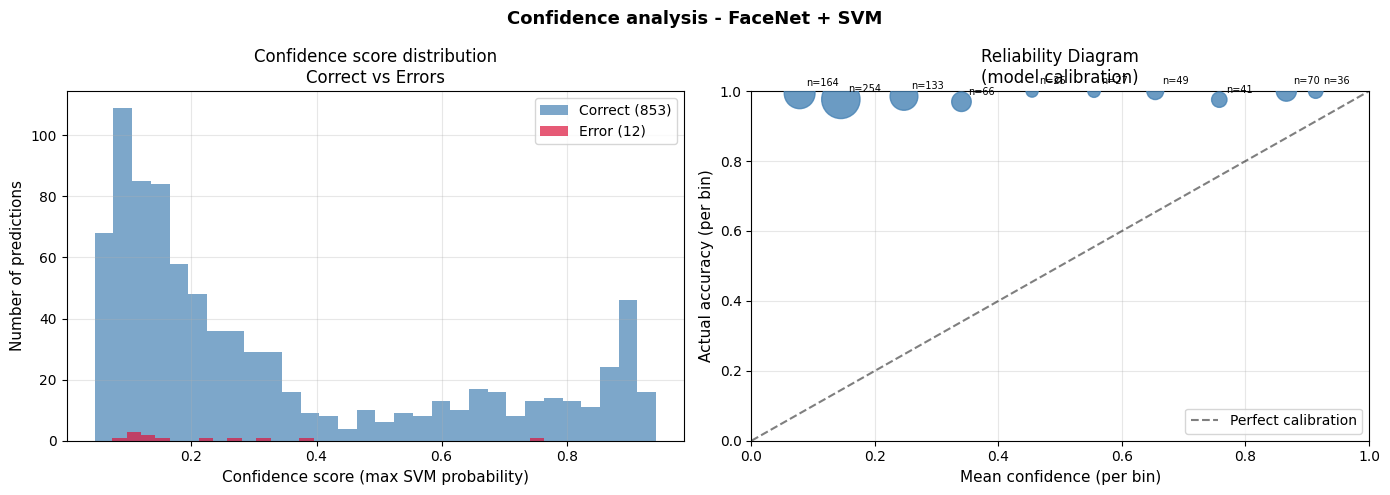


 Mean confidence - Correct : 0.334
   Mean confidence - Error   : 0.230


In [13]:
# -- Cell 13: Confidence score distribution ---------------------------
# Confidence = max probability given by the SVM (predict_proba)
# A good model is very confident on correct predictions, hesitant on errors

conf_scores = clf.predict_proba(X_test).max(axis=1)
correct      = (y_pred == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: correct vs error
axes[0].hist(conf_scores[correct],  bins=30, alpha=0.7,
             color='steelblue', label=f'Correct ({correct.sum()})')
axes[0].hist(conf_scores[~correct], bins=30, alpha=0.7,
             color='crimson',   label=f'Error ({(~correct).sum()})')
axes[0].set_xlabel('Confidence score (max SVM probability)', fontsize=11)
axes[0].set_ylabel('Number of predictions', fontsize=11)
axes[0].set_title('Confidence score distribution\nCorrect vs Errors', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Reliability diagram: is the confidence calibrated?
# In a perfect model: actual accuracy ~ mean confidence per bin
bins = np.linspace(0, 1, 11)
bin_acc, bin_conf, bin_count = [], [], []
for b_low, b_high in zip(bins[:-1], bins[1:]):
    mask_b = (conf_scores >= b_low) & (conf_scores < b_high)
    if mask_b.sum() > 0:
        bin_acc.append(correct[mask_b].mean())
        bin_conf.append(conf_scores[mask_b].mean())
        bin_count.append(mask_b.sum())

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect calibration')
axes[1].scatter(bin_conf, bin_acc,
                s=[c*3 for c in bin_count],
                color='steelblue', alpha=0.8, zorder=3)
for bc, ba, bn in zip(bin_conf, bin_acc, bin_count):
    axes[1].annotate(f'n={bn}', (bc, ba),
                     textcoords='offset points', xytext=(5,5), fontsize=7)
axes[1].set_xlabel('Mean confidence (per bin)', fontsize=11)
axes[1].set_ylabel('Actual accuracy (per bin)', fontsize=11)
axes[1].set_title('Reliability Diagram\n(model calibration)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Confidence analysis - FaceNet + SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Mean confidence - Correct : {conf_scores[correct].mean():.3f}")
print(f"   Mean confidence - Error   : {conf_scores[~correct].mean():.3f}")